In [3]:
import utils
import methods
from methods import Reservoir, DataGenerator

import torch

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import scipy.io as sio

# Data Analysis

In the following we aim to analyze the datasets. 

To evaluate the performance of the different training approache in probabilistic forecasting of chaotic time-series we use a chaotic benchmark and two experimental datasets containing rs-fMRI brain signal from the same subject.

The Synthetic Dataset will serve as the controlled environment. It will be used to prove our Bayesian algorithms and ESN are implemented correctly. 

The real brain data is noisy, high-dimensional, and stochastic. We will use it to evaluate how your different inference methods (MCMC vs. VI vs. SSVS) scale, perform, and degrade when the theoretical guarantees given by a deterministic model disappear.

## Synthetic Dataset

### Mackey–Glass Equation

The Mackey–Glass delay differential equation (continuous form):

$$
\frac{dx(t)}{dt} = \beta \frac{x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t)
$$

We use a discrete Euler approximation in the generator implemented in this notebook:

$$
x_{t+\Delta t} = x_t + \Delta t \left( \beta \frac{x_{t-\tau}}{1 + x_{t-\tau}^n} - \gamma x_t \right)
$$

Where: $\tau$ is the delay, $n$ the nonlinearity exponent, $\beta$ and $\gamma$ are parameters controlling feedback and decay, and $\Delta t$ is the integration step.

For the Mackey-Glass system generated with a physical delay $\tau$ and integration step $\Delta t$, the discrete delay index is calculated as $\tau/\Delta t$.


In [108]:
Time_steps = 1200
tau = 32
n = 10
beta = 0.2
gamma = 0.10
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n=10, beta=0.2, gamma=0.1, delta_t=0.1, init_steps=500 , under_samp=32).generate_data()

synth_1D = np.asarray(X).squeeze()

input_dim = X.shape[1]
reservoir_dim = 500
spectral_radius = 0.9
seed = 42

res = Reservoir(input_dim, reservoir_dim, spectral_radius, seed)

S = res.get_states(X)

print(f"Input shape: {X.shape}")

print(f"Reservoir States shape: {S.shape}")

Input shape: (1200, 1)
Reservoir States shape: (1200, 500)


In [ ]:
synth_data = (X - X.mean()) / ( X.std() + 1e-8 )
synth_1D = np.asarray(X).squeeze()

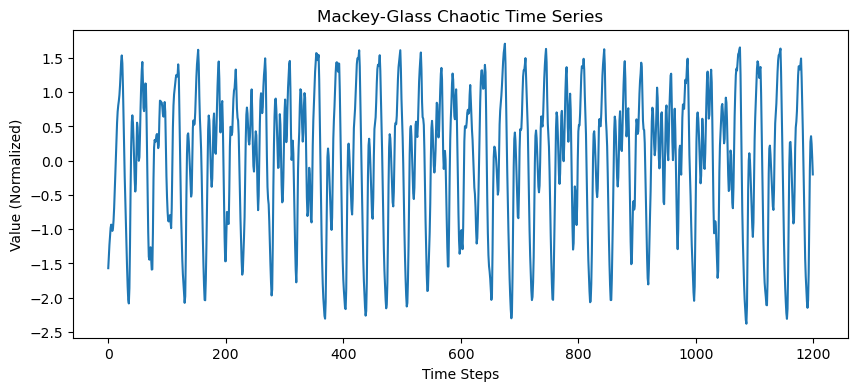

In [121]:
plt.figure(figsize=(10, 4))
plt.plot(synth_data)
plt.title("Mackey-Glass Chaotic Time Series")
plt.xlabel("Time Steps")
plt.ylabel("Value (Normalized)")
plt.show()

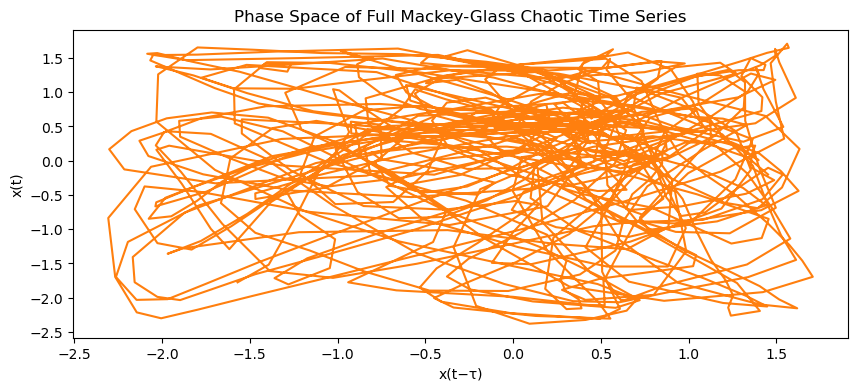

In [122]:
delay_steps = int(tau / delta_t)

plt.figure(figsize=(10, 4))
plt.plot(synth_data[:-delay_steps], synth_data[delay_steps:], color='C1')
plt.title("Phase Space of Full Mackey-Glass Chaotic Time Series")
plt.xlabel("x(t−τ)")
plt.ylabel("x(t)")
plt.show()

## Real dataset

We load the real fMRI time series and compare basic statistics, power spectra and autocorrelations with the synthetic Mackey–Glass series.

In [112]:
# Load the MAT file
mat_file1 = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
mat_file2 = sio.loadmat('100307.REST2.LR.SchaeferS.ptseries.mat')

In [113]:
real_data1 = torch.from_numpy(mat_file1['tseries']).float().T
real1_np = real_data1.cpu().numpy()
real1_np.shape

(1200, 119)

In [114]:
real_data2 = torch.from_numpy(mat_file2['tseries']).float().T
real2_np = real_data2.cpu().numpy()
real2_np.shape

(1200, 119)

### Understand `real_data`

We standardize the real dataset to a `(TimeSteps, Regions)` NumPy Array, verify shapes and basic statistics, as well as functional correlations.

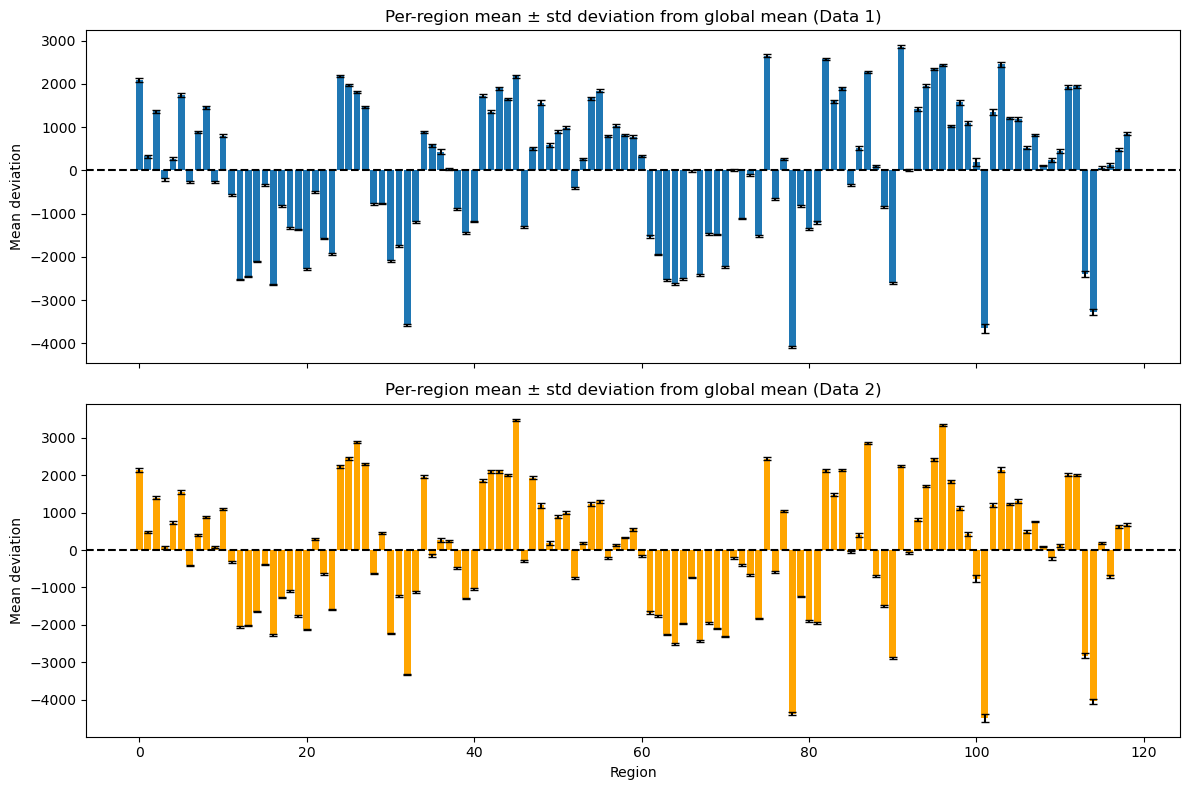

In [115]:
# Compute deviations from the global mean time-series (Data 1)
global1_mean = real1_np.mean(axis=1)
dev1 = real1_np - global1_mean[:, None]

region1_dev_mean = dev1.mean(axis=0)
region1_dev_std  = dev1.std(axis=0)

# Compute deviations from the global mean time-series (Data 2)
global2_mean = real2_np.mean(axis=1)
dev2 = real2_np - global2_mean[:, None]

region2_dev_mean = dev2.mean(axis=0)
region2_dev_std  = dev2.std(axis=0)

# Create vertically stacked subplots sharing the x-axis
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# Plot Data 1 on the top subplot
axes[0].bar(np.arange(len(region1_dev_mean)), region1_dev_mean, yerr=region1_dev_std, capsize=3)
axes[0].axhline(0, color='k', linestyle='--')
axes[0].set_ylabel('Mean deviation')
axes[0].set_title('Per-region mean ± std deviation from global mean (Data 1)')

# Plot Data 2 on the bottom subplot
axes[1].bar(np.arange(len(region2_dev_mean)), region2_dev_mean, yerr=region2_dev_std, capsize=3, color="orange")
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_ylabel('Mean deviation')
axes[1].set_xlabel('Region')
axes[1].set_title('Per-region mean ± std deviation from global mean (Data 2)')

plt.tight_layout()
plt.show()

In [116]:
real1_z = (real1_np - real1_np.mean(axis=0)) / (real1_np.std(axis=0)  + 1e-8)
real2_z = (real2_np - real2_np.mean(axis=0)) / (real2_np.std(axis=0)  + 1e-8)

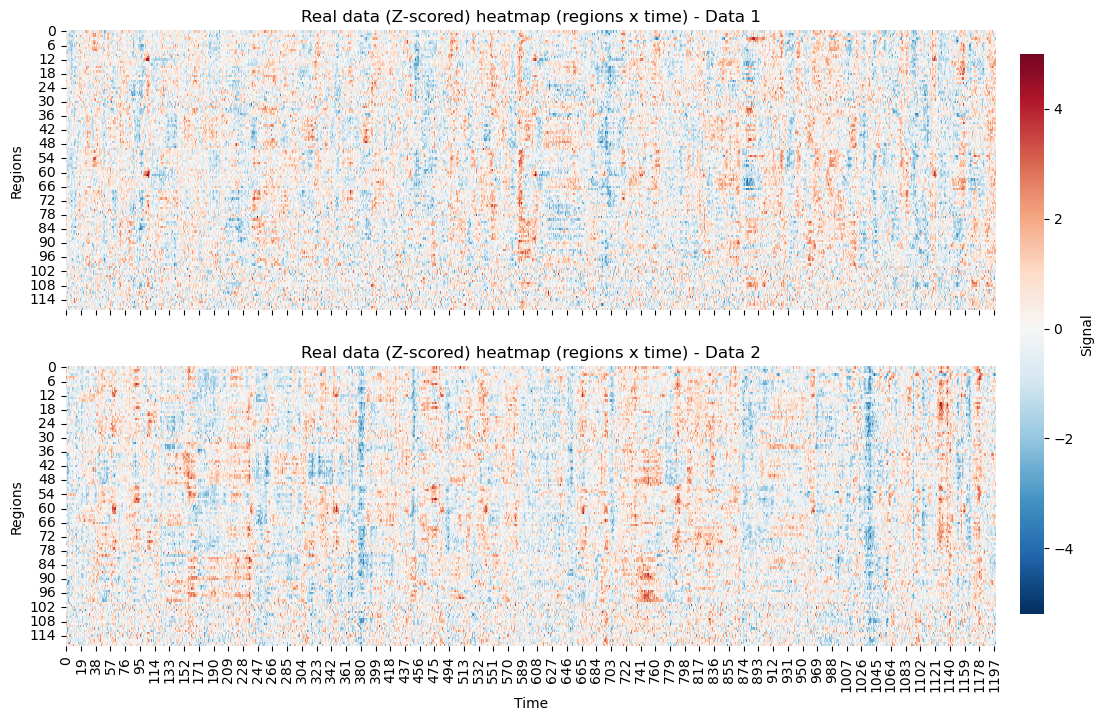

In [117]:
# Determine global min and max to ensure the shared colorbar is accurate for both datasets
vmin_sig = min(real1_z.min(), real2_z.min())
vmax_sig = max(real1_z.max(), real2_z.max())

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# Create a dedicated axis for the colorbar: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 

# Data 1 (Top)
sns.heatmap(real1_z.T, cmap='RdBu_r', center=0, vmin=vmin_sig, vmax=vmax_sig, 
            ax=axes[0], cbar=False)
axes[0].set_title('Real data (Z-scored) heatmap (regions x time) - Data 1')
axes[0].set_ylabel('Regions')

# Data 2 (Bottom)
sns.heatmap(real2_z.T, cmap='RdBu_r', center=0, vmin=vmin_sig, vmax=vmax_sig, 
            ax=axes[1], cbar=True, cbar_ax=cbar_ax, cbar_kws={'label':'Signal'})
axes[1].set_title('Real data (Z-scored) heatmap (regions x time) - Data 2')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Regions')

# Adjust layout to prevent overlap with the colorbar
plt.subplots_adjust(right=0.9)
plt.show()

Hint of spatial coupling across regions.

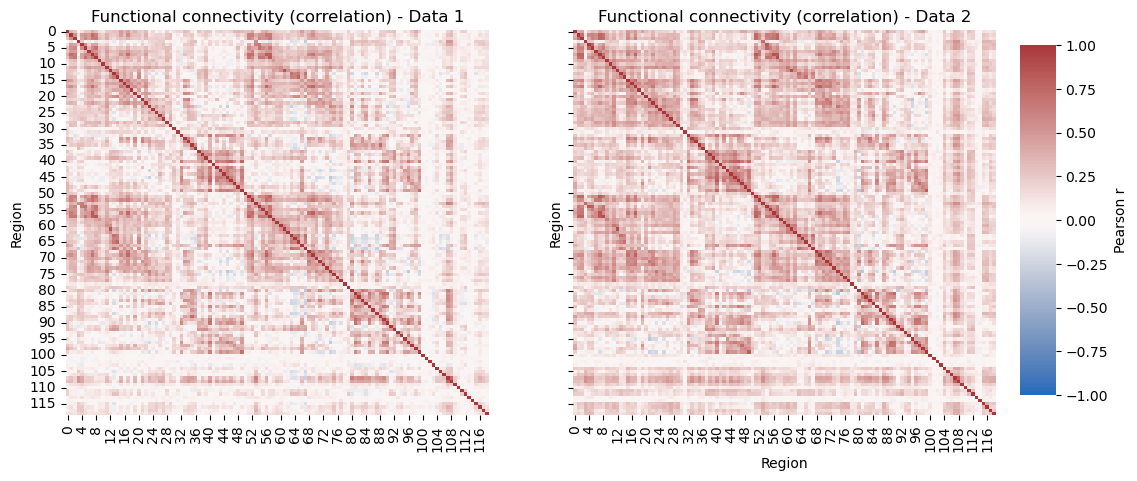

In [118]:
corr1 = np.corrcoef(real1_z.T)
corr2 = np.corrcoef(real2_z.T)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharex=True, sharey=True)

# Create a dedicated axis for the colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7]) 

# Data 1 (Top)
sns.heatmap(corr1, vmin=-1, vmax=1, cmap='vlag', 
            ax=axes[0], cbar=False)
axes[0].set_title('Functional connectivity (correlation) - Data 1')
axes[0].set_ylabel('Region')

# Data 2 (Bottom)
sns.heatmap(corr2, vmin=-1, vmax=1, cmap='vlag', 
            ax=axes[1], cbar=True, cbar_ax=cbar_ax, cbar_kws={'label':'Pearson r'})
axes[1].set_title('Functional connectivity (correlation) - Data 2')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Region')

# Adjust layout to prevent overlap with the colorbar
plt.subplots_adjust(right=0.9)
plt.show()

Hint of spatial coupling and high-dimensional cross-talk across several regions.

# Comparison

In [119]:
region_idx = np.random.choice(real_data1.shape[1])
real_region_z = real1_z[:, region_idx]

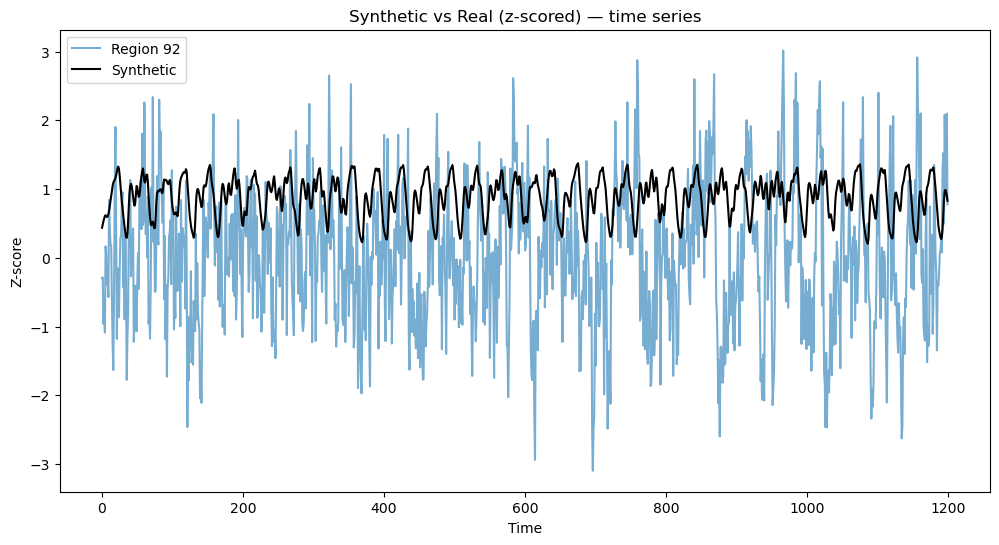

In [120]:
# Visualize stacked plots

plt.figure(figsize=(12,6))
plt.plot(real_region_z, alpha=0.6, label=f'Region {region_idx}')
plt.plot(synth_1D, alpha=1, label='Synthetic', color='black')
plt.legend()
plt.title('Synthetic vs Real (z-scored) — time series')
plt.xlabel('Time')
plt.ylabel('Z-score')
plt.show()

From the overlay of the two datasets we visualize whether with the selected paramters the MG dataset, despite being very different, somewhat resembles the variability of the real datatset, in the hope that a good performance on the synthetic dataset can lead to a decent performance on the brain data. 